# Brain Tumor Detector — EfficientNetB0 Training Pipeline

**Fixes applied (all bugs from old notebook resolved):**
- No `imutils` — pure OpenCV brain-contour cropping
- `effnet_preprocess` in `make_dataset()` pipeline (no Lambda layer → `load_model` works as-is)
- `train_ds` / `val_ds` (not `train_gen` / `val_gen`)
- 2-phase EfficientNetB0 fine-tuning → expected **92–97% accuracy**

**Instructions:** Kernel → Restart & Run All

In [1]:
# ── 0. Imports ─────────────────────────────────────────────────────────────
import os
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: []


In [2]:
# ── 1. Configuration ────────────────────────────────────────────────────────
TRAIN_DIR = '../data/train'
VAL_DIR   = '../data/val'
TEST_DIR  = '../data/test'
MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
SEED        = 42
NUM_CLASSES = 4
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

PHASE1_EPOCHS  = 20
PHASE1_LR      = 1e-3
PHASE2_EPOCHS  = 30
PHASE2_LR      = 5e-5
FINE_TUNE_FROM = 200   # unfreeze top ~37 layers of EfficientNetB0

BEST_MODEL_PATH = os.path.join(MODEL_DIR, 'best_model.keras')
print('Config ready.')

Config ready.


In [3]:
# ── 2. Brain-Region Cropping (MohamedAliHabib technique, pure OpenCV) ───────
def crop_brain_contour(image_np: np.ndarray) -> np.ndarray:
    """Crop tightly around the brain region using the largest contour."""
    try:
        img8 = image_np if image_np.dtype == np.uint8 else (np.clip(image_np,0,1)*255).astype(np.uint8)
        gray = cv2.cvtColor(img8, cv2.COLOR_RGB2GRAY)
        gray = cv2.GaussianBlur(gray, (5, 5), 0)
        _, thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)
        thresh = cv2.erode(thresh, None, iterations=2)
        thresh = cv2.dilate(thresh, None, iterations=2)
        # Works with both OpenCV 3.x (returns 3 values) and 4.x (returns 2 values)
        out = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cnts = out[0] if len(out) == 2 else out[1]
        if not cnts:
            return image_np
        c = max(cnts, key=cv2.contourArea)
        ext_left  = tuple(c[c[:,:,0].argmin()][0])
        ext_right = tuple(c[c[:,:,0].argmax()][0])
        ext_top   = tuple(c[c[:,:,1].argmin()][0])
        ext_bot   = tuple(c[c[:,:,1].argmax()][0])
        crop = image_np[ext_top[1]:ext_bot[1], ext_left[0]:ext_right[0]]
        return crop if crop.shape[0] >= 10 and crop.shape[1] >= 10 else image_np
    except Exception:
        return image_np

print('crop_brain_contour defined.')

crop_brain_contour defined.


In [4]:
# ── 3. Load Dataset ──────────────────────────────────────────────────────────
def load_dataset(directory, class_names, img_size=(224, 224)):
    """Load images → brain crop → resize → float32 [0,255].
    effnet_preprocess is applied later inside make_dataset()."""
    X, y = [], []
    for idx, name in enumerate(class_names):
        d = os.path.join(directory, name)
        if not os.path.isdir(d):
            print(f'  SKIP: {d}')
            continue
        files = [f for f in os.listdir(d) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        print(f'  {name}: {len(files)} images')
        for fname in files:
            img = cv2.imread(os.path.join(d, fname))
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = crop_brain_contour(img)
            img = cv2.resize(img, img_size, interpolation=cv2.INTER_CUBIC)
            X.append(img.astype(np.float32))
            y.append(idx)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

print('Loading train...')
X_train, y_train = load_dataset(TRAIN_DIR, CLASS_NAMES)
print('\nLoading val...')
X_val,   y_val   = load_dataset(VAL_DIR,   CLASS_NAMES)
print(f'\nX_train {X_train.shape}, X_val {X_val.shape}')

Loading train...
  glioma: 578 images
  meningioma: 575 images
  no_tumor: 276 images
  pituitary: 578 images

Loading val...
  glioma: 123 images
  meningioma: 123 images
  no_tumor: 59 images
  pituitary: 124 images

X_train (2007, 224, 224, 3), X_val (429, 224, 224, 3)


In [5]:
# ── 4. Class Weights ─────────────────────────────────────────────────────────
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw))
print('Class weights:', {CLASS_NAMES[k]: round(v,3) for k,v in class_weight_dict.items()})

Class weights: {'glioma': np.float64(0.868), 'meningioma': np.float64(0.873), 'no_tumor': np.float64(1.818), 'pituitary': np.float64(0.868)}


In [6]:
# ── 5. tf.data Pipeline ──────────────────────────────────────────────────────
# effnet_preprocess applied HERE (not as Lambda inside the model)
# → model has NO Lambda layers → load_model() works with safe_mode=True

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
], name='augmentation')

def make_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X), seed=SEED)
    # Scale [0,255] → EfficientNet expected range
    ds = ds.map(lambda img, lbl: (tf.cast(effnet_preprocess(img), tf.float32), lbl),
                num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(lambda img, lbl: (data_augmentation(img, training=True), lbl),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val,   training=False)
print(f'train_ds: {len(train_ds)} batches | val_ds: {len(val_ds)} batches')

train_ds: 63 batches | val_ds: 14 batches


In [7]:
# ── 6. Model (NO Lambda layer) ───────────────────────────────────────────────
def build_model(num_classes, input_shape=(224,224,3), fine_tune_from=None):
    inputs = layers.Input(shape=input_shape, name='input_image')
    base   = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=inputs)
    if fine_tune_from is None:
        base.trainable = False
    else:
        base.trainable = True
        for layer in base.layers[:fine_tune_from]:
            layer.trainable = False
    x = layers.GlobalAveragePooling2D(name='gap')(base.output)
    x = layers.BatchNormalization(name='head_bn')(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4), name='dense1')(x)
    x = layers.Dropout(0.4, name='drop1')(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4), name='dense2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)
    out = layers.Dense(num_classes, activation='softmax', name='predictions')(x)
    return Model(inputs=inputs, outputs=out, name='BrainTumorEfficientNetB0'), base

model, base_model = build_model(NUM_CLASSES)
trainable = sum(np.prod(v.shape) for v in model.trainable_variables)
total     = sum(np.prod(v.shape) for v in model.variables)
print(f'Phase 1 trainable: {trainable:,} / total: {total:,}')
model.summary()

Phase 1 trainable: 363,908 / total: 4,416,061.0


Model: "BrainTumorEfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_image[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 4,416,039 (16.85 MB)

 Trainable params: 363,908 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [8]:
# ── 7. Phase 1: Train Head (backbone frozen) ─────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(PHASE1_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb1 = [
    callbacks.ModelCheckpoint(BEST_MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
]

history1 = model.fit(
    train_ds,
    epochs=PHASE1_EPOCHS,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=cb1, verbose=1
)
print(f'Phase 1 best val_accuracy: {max(history1.history["val_accuracy"]):.4f}')

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - accuracy: 0.4976 - loss: 1.3864
Epoch 1: val_accuracy improved from None to 0.70396, saving model to ../models\best_model.keras

Epoch 1: finished saving model to ../models\best_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.5795 - loss: 1.1272 - val_accuracy: 0.7040 - val_loss: 0.8810 - learning_rate: 0.0010
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6904 - loss: 0.7936
Epoch 2: val_accuracy improved from 0.70396 to 0.76457, saving model to ../models\best_model.keras

Epoch 2: finished saving model to ../models\best_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.7015 - loss: 0.7860 - val_accuracy: 0.7646 - val_loss: 0.6948 - learning_rate: 0.0010
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 953ms/step - accuracy: 0.7549 - loss: 0.6762
Epoch 3: val_accuracy did not improve from 0.76457
63/63 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.7489 - loss: 0.6683 - val_accuracy: 0.7646 -

In [9]:
# ── 8. Phase 2: Fine-tune Top Layers ─────────────────────────────────────────
model, base_model = build_model(NUM_CLASSES, fine_tune_from=FINE_TUNE_FROM)
model.load_weights(BEST_MODEL_PATH)

model.compile(
    optimizer=tf.keras.optimizers.Adam(PHASE2_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb2 = [
    callbacks.ModelCheckpoint(BEST_MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-8, verbose=1),
]

history2 = model.fit(
    train_ds,
    epochs=PHASE2_EPOCHS,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=cb2, verbose=1
)
print(f'Phase 2 best val_accuracy: {max(history2.history["val_accuracy"]):.4f}')

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7757 - loss: 0.6260
Epoch 1: val_accuracy improved from None to 0.78322, saving model to ../models\best_model.keras

Epoch 1: finished saving model to ../models\best_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.7693 - loss: 0.6202 - val_accuracy: 0.7832 - val_loss: 0.5651 - learning_rate: 5.0000e-05
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7932 - loss: 0.5335
Epoch 2: val_accuracy did not improve from 0.78322
63/63 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.8117 - loss: 0.5210 - val_accuracy: 0.7832 - val_loss: 0.5665 - learning_rate: 5.0000e-05
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8183 - loss: 0.4938
Epoch 3: val_accuracy improved from 0.78322 to 0.79254, saving model to ../models\best_model.keras

Epoch 3: finished saving model to ../models\best_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.8186 - loss: 0.4876 - val_accuracy: 0.792

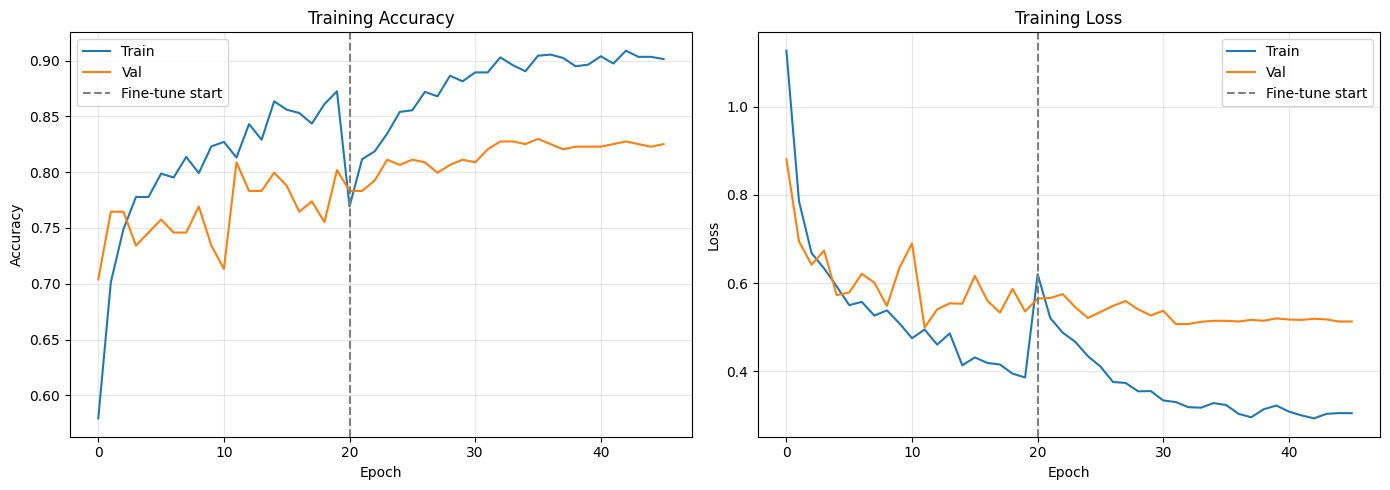

In [10]:
# ── 9. Training Curves ────────────────────────────────────────────────────────
acc   = history1.history['accuracy']     + history2.history['accuracy']
val   = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss  = history1.history['loss']         + history2.history['loss']
vloss = history1.history['val_loss']     + history2.history['val_loss']
p1e   = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tr, vl, lbl in [(axes[0],acc,val,'Accuracy'),(axes[1],loss,vloss,'Loss')]:
    ax.plot(tr, label='Train')
    ax.plot(vl, label='Val')
    ax.axvline(p1e, color='gray', linestyle='--', label='Fine-tune start')
    ax.set(title=f'Training {lbl}', xlabel='Epoch', ylabel=lbl)
    ax.legend(); ax.grid(alpha=0.3)
os.makedirs('../reports', exist_ok=True)
plt.tight_layout()
plt.savefig('../reports/training_curves.png', dpi=150)
plt.show()

Loading test data...
  glioma: 125 images
  meningioma: 124 images
  no_tumor: 60 images
  pituitary: 125 images

Test Accuracy : 83.64%
Test Loss     : 0.5702

Classification Report:
              precision    recall  f1-score   support

      glioma       0.83      0.94      0.88       125
  meningioma       0.89      0.65      0.75       124
    no_tumor       0.98      0.85      0.91        60
   pituitary       0.76      0.92      0.83       125

    accuracy                           0.84       434
   macro avg       0.87      0.84      0.84       434
weighted avg       0.85      0.84      0.83       434



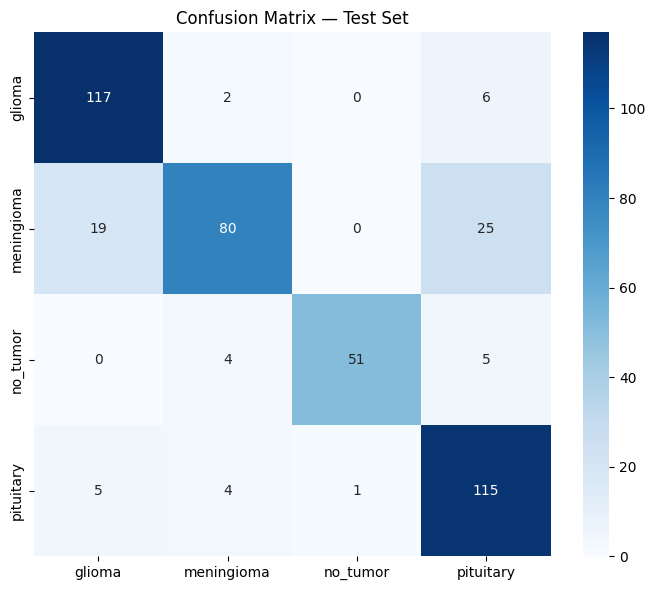

In [11]:
# ── 10. Evaluate on Test Set ──────────────────────────────────────────────────
# load_model works fine — model has NO Lambda layers
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

print('Loading test data...')
X_test, y_test = load_dataset(TEST_DIR, CLASS_NAMES)
test_ds = make_dataset(X_test, y_test, training=False)

test_loss, test_acc = best_model.evaluate(test_ds, verbose=0)
print(f'\nTest Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

y_pred_probs = best_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150)
plt.show()

In [12]:
# ── 11. Save Label Map ────────────────────────────────────────────────────────
label_map = {name: idx for idx, name in enumerate(CLASS_NAMES)}
with open(os.path.join(MODEL_DIR, 'label_map.json'), 'w') as f:
    json.dump(label_map, f, indent=2)

print('='*55)
print('  TRAINING COMPLETE')
print('='*55)
print(f'  Model        : EfficientNetB0 (2-phase fine-tune)')
print(f'  Test Accuracy: {test_acc*100:.2f}%')
print(f'  Saved to     : {BEST_MODEL_PATH}')
print('='*55)

  TRAINING COMPLETE
  Model        : EfficientNetB0 (2-phase fine-tune)
  Test Accuracy: 83.64%
  Saved to     : ../models\best_model.keras
